
# Notebook 15 - Topic Classification: Pipeline vs LLM Comparison

## Methodology

### Two-stage design
**Stage 1 (Notebook 06b):** BERTopic discovers topics from the full 1115-article corpus.
BERTopic is a corpus analysis tool only - it does NOT participate in classification or gold standard construction.

**Stage 2 (this notebook):** Three NLI pipelines and four LLMs independently classify
183 validation articles into a 6+OTHER taxonomy derived from BERTopic topics.
Dual gold standard mirrors Notebook 14 exactly.

### Language approach
All category labels, descriptions, NLI hypothesis templates, and LLM DE-condition prompts
are fully in **German** to avoid cross-lingual hypothesis mismatch.
LLM EN condition uses English article text with English labels and descriptions.

### Gold standards
- **Pipeline Gold:** full 3/3 agreement across all three NLI pipelines
- **LLM Gold DE:** full agreement of Scout 17B + Qwen3 32B + Llama 70B (DE input)
- Evaluation on shared intersection of complete runs


In [4]:

# CELL 1 : INSTALL
!pip install -q cerebras-cloud-sdk
!pip install -q transformers torch accelerate sentencepiece
!pip install -q groq
!pip install -q scikit-learn scipy matplotlib seaborn
!pip install -q 'numpy>=2.0'
import numpy as np
print(f"numpy {np.__version__}")
print("Installs complete")


numpy 2.0.2
Installs complete


In [5]:
# CELL 2 : IMPORTS AND CONFIGURATION
import os, json, pickle, time, re
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from google.colab import drive, userdata

drive.mount("/content/drive", force_remount=False)

ROOT        = Path("/content/drive/MyDrive/thesis")
DATA_PROC   = ROOT / "Project/Data/Processed"
FIGURES_DIR = ROOT / "Project/Outputs/Figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GROQ_TOKEN = userdata.get("GROQ_TOKEN")
CEREBRAS_TOKEN = userdata.get("CEREBRAS_TOKEN")

# ── German category labels ------------------------------------------------
# All labels and descriptions in German to ensure full linguistic consistency
# across NLI hypothesis templates and LLM DE-condition prompts.

CATEGORIES_DE = [
    "Energieeffizienz und Gebaeudesanierung",
    "Wohnungsmarkt, Erschwinglichkeit und Finanzierung",
    "Nachhaltige Baustoffe und Konstruktion",
    "Architektur, Stadtplanung und Bauentwicklung",
    "Klima- und Energiepolitik",
    "Wohngebaeude und Haustypen",
    "SONSTIGES",
]

CATEGORY_DESCRIPTIONS_DE = {
    "Energieeffizienz und Gebaeudesanierung":
        "Waermepumpen, Daemmung, energetische Sanierung von Gebaeuden, "
        "CO2-Reduzierung im Gebaeudebestand, Energieausweis, Fenstererneuerung",
    "Wohnungsmarkt, Erschwinglichkeit und Finanzierung":
        "Mietpreise, Wohnungsmangel, bezahlbares Wohnen, Immobilienmarkt, "
        "KfW-Foerderung, staatliche Wohnungsprogramme, Hypothekenzinsen",
    "Nachhaltige Baustoffe und Konstruktion":
        "Holzbau, Holz als Baustoff, recycelte Baumaterialien, "
        "Betonrecycling, Kreislaufwirtschaft im Bau, nachhaltige Inneneinrichtung",
    "Architektur, Stadtplanung und Bauentwicklung":
        "Architekten, Gebaeudegestaltung, Stadtplanung, Bauvorschriften, "
        "Abriss und Neubau, Denkmalschutz, Baugenehmigungen",
    "Klima- und Energiepolitik":
        "Politik zu erneuerbaren Energien, staatliche Klimaschutzmassnahmen, "
        "EU-Energievorschriften, Energiewende, Wasserstoffwirtschaft, Klimaziele",
    "Wohngebaeude und Haustypen":
        "Tiny Houses, Fertighaeuser, Einfamilienhaeuser, Campusgebaeude, "
        "Gemeinschaftswohnprojekte, Selbstbau, Studentenwohnheime",
    "SONSTIGES":
        "Artikel, die in keine der obigen Kategorien passen, "
        "oder ueber nicht verwandte Themen wie Autos, Landwirtschaft oder Tourismus handeln",
}

# English equivalents (used for LLM EN condition and results display)
CATEGORIES_EN = [
    "Energy Efficiency and Renovation",
    "Housing Market Affordability and Financing",
    "Sustainable Materials and Construction",
    "Architecture Planning and Urban Development",
    "Climate and Energy Policy",
    "Residential Building Types",
    "OTHER",
]

CATEGORY_DESCRIPTIONS_EN = {
    "Energy Efficiency and Renovation":
        "heat pumps, thermal insulation, energy renovation of buildings, "
        "reducing CO2 in existing buildings, energy certificates, window replacement",
    "Housing Market Affordability and Financing":
        "rent prices, housing shortage, affordable housing, real estate market, "
        "KfW subsidies, government housing grants, mortgage rates, housing programs",
    "Sustainable Materials and Construction":
        "timber construction, wood as building material, recycled building materials, "
        "concrete recycling, circular construction, sustainable interior design",
    "Architecture Planning and Urban Development":
        "architects, building design, urban planning, building regulations, "
        "demolition and redevelopment, historic buildings, construction permits",
    "Climate and Energy Policy":
        "renewable energy policy, government climate action plans, EU energy regulations, "
        "energy transition, hydrogen economy, climate targets, political energy decisions",
    "Residential Building Types":
        "tiny houses, prefabricated homes, single-family houses, campus buildings, "
        "community housing projects, self-build housing, student accommodation",
    "OTHER":
        "articles that do not fit any of the above categories, "
        "or are about unrelated topics such as cars, agriculture, or tourism",
}

DE_TO_EN = dict(zip(CATEGORIES_DE, CATEGORIES_EN))
EN_TO_DE = {v: k for k, v in DE_TO_EN.items()}

# BERTopic topic id -> German category label
TOPIC_TO_CATEGORY = {
    16: "Energieeffizienz und Gebaeudesanierung",
     9: "Wohnungsmarkt, Erschwinglichkeit und Finanzierung",
    10: "Wohnungsmarkt, Erschwinglichkeit und Finanzierung",
    14: "Wohnungsmarkt, Erschwinglichkeit und Finanzierung",
    11: "Nachhaltige Baustoffe und Konstruktion",
    15: "Nachhaltige Baustoffe und Konstruktion",
    22: "Nachhaltige Baustoffe und Konstruktion",
     7: "Architektur, Stadtplanung und Bauentwicklung",
    21: "Architektur, Stadtplanung und Bauentwicklung",
    23: "Architektur, Stadtplanung und Bauentwicklung",
    24: "Architektur, Stadtplanung und Bauentwicklung",
     4: "Klima- und Energiepolitik",
    17: "Klima- und Energiepolitik",
    18: "Klima- und Energiepolitik",
     5: "Wohngebaeude und Haustypen",
     6: "Wohngebaeude und Haustypen",
    13: "Wohngebaeude und Haustypen",
}

NLI_MODELS = {
    "mDeBERTa-NLI"      : "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    "XLM-RoBERTa-NLI"   : "joeddav/xlm-roberta-large-xnli",
    "DeBERTa-TaskSource" : "sileod/deberta-v3-base-tasksource-nli",
}

LLM_MODELS = {
    "llama-3.1-8b-instant"                     : {"scale_B": 8,  "family": "llama"},
    "meta-llama/llama-4-scout-17b-16e-instruct": {"scale_B": 17, "family": "llama4"},
    "qwen/qwen3-32b"                           : {"scale_B": 32, "family": "qwen3"},
    "llama-3.3-70b-versatile"                  : {"scale_B": 70, "family": "llama"},
}

LLM_GOLD_MODELS = [
    "meta-llama/llama-4-scout-17b-16e-instruct",
    "qwen/qwen3-32b",
    "llama-3.3-70b-versatile",
]

SAVE_EVERY               = 4
MAX_CONSECUTIVE_FAILURES = 5
RETRY_DELAYS             = [30, 60, 120]
MODEL_SLEEP = {
    "llama-3.3-70b-versatile"                  : 45.0,
    "meta-llama/llama-4-scout-17b-16e-instruct": 4.0,
    "qwen/qwen3-32b"                           : 3.0,
    "llama-3.1-8b-instant"                     : 2.0,
}

print("Configuration loaded")
print(f"  Categories (DE) : {len(CATEGORIES_DE)}")
print(f"  NLI models      : {list(NLI_MODELS.keys())}")
print(f"  LLM models      : {list(LLM_MODELS.keys())}")

Mounted at /content/drive
Configuration loaded
  Categories (DE) : 7
  NLI models      : ['mDeBERTa-NLI', 'XLM-RoBERTa-NLI', 'DeBERTa-TaskSource']
  LLM models      : ['llama-3.1-8b-instant', 'meta-llama/llama-4-scout-17b-16e-instruct', 'qwen/qwen3-32b', 'llama-3.3-70b-versatile']


In [6]:

# CELL 3 : LOAD DATA

print("Loading data...")
pipeline_df = pd.read_pickle(DATA_PROC / "ner_pipeline_results.pkl")
assignments = pd.read_csv(DATA_PROC / "topic_assignments_v2.csv")

# Validation set IDs (same 183 articles used throughout thesis)
with open(DATA_PROC / "ner_llm_checkpoint.pkl", "rb") as f:
    qwen_ckpt = pickle.load(f)
VAL_IDS = set(
    aid for aid, data in qwen_ckpt.items()
    if isinstance(data, dict) and data.get("status") != "api_error"
)
print(f"  Validation set  : {len(VAL_IDS)} articles")

val_df = pipeline_df[pipeline_df["article_id"].isin(VAL_IDS)].copy().reset_index(drop=True)
print(f"  Found in corpus : {len(val_df)} articles")

# Add BERTopic-derived category for reference only (NOT used as gold standard)
art_to_topic = dict(zip(assignments["article_id"], assignments["topic"]))
val_df["bertopic_topic"]    = val_df["article_id"].map(art_to_topic)
val_df["bertopic_category"] = val_df["bertopic_topic"].map(TOPIC_TO_CATEGORY).fillna("SONSTIGES")

# Text lookups
id_to_de = dict(zip(val_df["article_id"], val_df["content"]))
id_to_en = dict(zip(val_df["article_id"], val_df["content_en"]))
ARTICLE_IDS = val_df["article_id"].tolist()

print("\n  BERTopic category distribution (reference only):")
print(val_df["bertopic_category"].value_counts().to_string())
print("\n  Data loaded")


Loading data...
  Validation set  : 183 articles
  Found in corpus : 183 articles

  BERTopic category distribution (reference only):
bertopic_category
SONSTIGES                                            79
Klima- und Energiepolitik                            32
Architektur, Stadtplanung und Bauentwicklung         24
Wohngebaeude und Haustypen                           14
Wohnungsmarkt, Erschwinglichkeit und Finanzierung    13
Energieeffizienz und Gebaeudesanierung               11
Nachhaltige Baustoffe und Konstruktion               10

  Data loaded


In [7]:
# CELL 4 : NLI PIPELINE CLASSIFICATION
#
# Three NLI models classify each article using German text (first 500 chars).
#
# Hypothesis template: "Das Hauptthema dieses Artikels ist {category}."
# Selected after empirical testing of 4 formulations:
#   (a) full descriptions → near-random (margin <0.01)
#   (b) short keywords    → functional  (margin ~0.12-0.34)
#   (c) "Hauptthema" + category names → best (margin 0.10-0.52) ← SELECTED
#   (d) sigmoid scoring   → destroyed discrimination
#
# Text truncated to 500 chars (lead paragraph) because:
#   - NLI discrimination degrades with longer input (tested 300-2000 chars)
#   - Lead paragraph carries strongest topical signal in news articles
#
# Re-running is safe -- checkpoints saved per model to Drive.

import sys, time
from transformers import pipeline as hf_pipeline

NLI_TEMPLATE = "Das Hauptthema dieses Artikels ist {}."
TEXT_LIMIT_NLI = 500

def ckpt_path_nli(model_name):
    safe = re.sub(r"[/\\:.*?<>|]", "_", model_name)
    return DATA_PROC / ("nb15_nli_" + safe + "_checkpoint.pkl")

def load_nli_ckpt(model_name):
    p = ckpt_path_nli(model_name)
    if p.exists():
        with open(p, "rb") as f:
            d = pickle.load(f)
        print(f"  Checkpoint: {len(d)} / {len(ARTICLE_IDS)} already done")
        return d
    return {}

def save_nli_ckpt(model_name, d):
    with open(ckpt_path_nli(model_name), "wb") as f:
        pickle.dump(d, f)

print(f"NLI hypothesis template: \"{NLI_TEMPLATE}\"")
print(f"Text limit: {TEXT_LIMIT_NLI} chars")
print(f"Candidate labels: {CATEGORIES_DE}")

nli_results = {}

for model_key, model_id in NLI_MODELS.items():
    print(f"\n{'='*65}")
    print(f"Model : {model_key}")
    print(f"ID    : {model_id}")

    results = load_nli_ckpt(model_key)
    todo    = [aid for aid in ARTICLE_IDS if aid not in results]
    print(f"Todo  : {len(todo)} articles remaining")

    if not todo:
        print("  Already complete -- skipping")
        nli_results[model_key] = results
        continue

    try:
        clf = hf_pipeline("zero-shot-classification",
                          model=model_id, device=0, multi_label=False)
        device_label = "GPU"
    except Exception as gpu_err:
        print(f"  GPU load failed ({gpu_err}), falling back to CPU")
        clf = hf_pipeline("zero-shot-classification",
                          model=model_id, device=-1, multi_label=False)
        device_label = "CPU"

    print(f"Device: {device_label}")
    print(f"{'':5} {'art_id':12}  {'predicted category':35}  {'score':5}  {'s/art':5}  {'ETA':8}  status")
    print("-" * 90)

    model_start = time.time()

    for idx, aid in enumerate(todo):
        art_start = time.time()
        text      = id_to_de[aid][:TEXT_LIMIT_NLI]

        try:
            out = clf(
                text,
                candidate_labels=CATEGORIES_DE,
                hypothesis_template=NLI_TEMPLATE,
                multi_label=False,
            )
            best       = out["labels"][0]
            best_score = out["scores"][0]
            results[aid] = {
                "predicted": best,
                "status"   : "ok",
                "scores"   : dict(zip(out["labels"], out["scores"])),
            }
            status = "ok"
        except Exception as e:
            best       = "SONSTIGES"
            best_score = 0.0
            results[aid] = {
                "predicted": "SONSTIGES",
                "status"   : "error",
                "error"    : str(e),
            }
            status = "error"

        art_elapsed   = time.time() - art_start
        total_elapsed = time.time() - model_start
        done_count    = idx + 1
        remaining     = len(todo) - done_count
        eta_s         = (total_elapsed / done_count) * remaining
        eta_min       = eta_s / 60
        best_short    = best[:35].ljust(35)

        print(
            f"  [{done_count:3d}/{len(todo)}] {aid:12s}  "
            f"{best_short}  {best_score:.3f}  "
            f"{art_elapsed:4.1f}s  ETA={eta_min:5.1f}m  {status}"
        )
        sys.stdout.flush()

        if done_count % SAVE_EVERY == 0:
            save_nli_ckpt(model_key, results)
            print(f"  >>> Checkpoint saved ({done_count} articles)")

    save_nli_ckpt(model_key, results)
    nli_results[model_key] = results

    ok        = sum(1 for v in results.values() if v.get("status") == "ok")
    total_min = (time.time() - model_start) / 60
    print(f"\n  Done: {ok}/{len(ARTICLE_IDS)} ok  |  total={total_min:.1f}min")

print("\nAll NLI models complete")
print({k: sum(1 for v in r.values() if v.get("status") == "ok")
       for k, r in nli_results.items()})

NLI hypothesis template: "Das Hauptthema dieses Artikels ist {}."
Text limit: 500 chars
Candidate labels: ['Energieeffizienz und Gebaeudesanierung', 'Wohnungsmarkt, Erschwinglichkeit und Finanzierung', 'Nachhaltige Baustoffe und Konstruktion', 'Architektur, Stadtplanung und Bauentwicklung', 'Klima- und Energiepolitik', 'Wohngebaeude und Haustypen', 'SONSTIGES']

Model : mDeBERTa-NLI
ID    : MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
  Checkpoint: 183 / 183 already done
Todo  : 0 articles remaining
  Already complete -- skipping

Model : XLM-RoBERTa-NLI
ID    : joeddav/xlm-roberta-large-xnli
  Checkpoint: 183 / 183 already done
Todo  : 0 articles remaining
  Already complete -- skipping

Model : DeBERTa-TaskSource
ID    : sileod/deberta-v3-base-tasksource-nli
  Checkpoint: 183 / 183 already done
Todo  : 0 articles remaining
  Already complete -- skipping

All NLI models complete
{'mDeBERTa-NLI': 183, 'XLM-RoBERTa-NLI': 183, 'DeBERTa-TaskSource': 183}


In [8]:
# CELL 5 : LLM PROMPT DEFINITIONS
#
# DE condition: German article text + German instructions + German category list
# EN condition: English article text + English instructions + English category list
# Each condition is fully monolingual end-to-end.

import groq as groq_lib

groq_client = groq_lib.Groq(api_key=GROQ_TOKEN) if GROQ_TOKEN else None
if groq_client:
    print("Groq client initialised")
else:
    print("WARNING: No GROQ_TOKEN -- LLM cells will be skipped")


# Cerebras client (70B only -- separate quota)
from cerebras.cloud.sdk import Cerebras
cerebras_client = Cerebras(api_key=CEREBRAS_TOKEN) if CEREBRAS_TOKEN else None
if cerebras_client:
    print("Cerebras client initialised")
else:
    print("WARNING: No CEREBRAS_TOKEN -- 70B will be skipped")

# Build category list strings
CATEGORY_LIST_DE = chr(10).join(
    '- ' + cat + ': ' + CATEGORY_DESCRIPTIONS_DE[cat]
    for cat in CATEGORIES_DE
)

CATEGORY_LIST_EN = chr(10).join(
    '- ' + cat + ': ' + CATEGORY_DESCRIPTIONS_EN[cat]
    for cat in CATEGORIES_EN
)

# German system prompt
SYSTEM_PROMPT_DE = (
    "Du bist ein Experte fuer die Klassifikation von Zeitungsartikeln.\n\n"
    "Klassifiziere den folgenden deutschen Zeitungsartikel in GENAU EINE"
    " der folgenden Kategorien:\n\n"
    + CATEGORY_LIST_DE +
    "\n\nAntworte NUR mit dem exakten deutschen Kategorienamen -- kein anderer Text,"
    " keine Erklaerung, keine Anfuehrungszeichen."
    "\nWenn der Artikel in keine Kategorie passt, antworte mit: SONSTIGES"
)

# English system prompt
SYSTEM_PROMPT_EN = (
    "You are an expert classifier of newspaper articles.\n\n"
    "Classify the following article into EXACTLY ONE of these categories:\n\n"
    + CATEGORY_LIST_EN +
    "\n\nReply with ONLY the exact category name -- no other text, no explanation, no quotes."
    "\nIf the article does not fit any category, reply with: OTHER"
)

VALID_LABELS_DE = set(CATEGORIES_DE)
VALID_LABELS_EN = set(CATEGORIES_EN)

print("Prompts defined")
print(f"  DE system prompt : {len(SYSTEM_PROMPT_DE)} chars")
print(f"  EN system prompt : {len(SYSTEM_PROMPT_EN)} chars")
print(f"  DE prompt preview:\n{SYSTEM_PROMPT_DE[:300]}...")

Groq client initialised
Cerebras client initialised
Prompts defined
  DE system prompt : 1504 chars
  EN system prompt : 1507 chars
  DE prompt preview:
Du bist ein Experte fuer die Klassifikation von Zeitungsartikeln.

Klassifiziere den folgenden deutschen Zeitungsartikel in GENAU EINE der folgenden Kategorien:

- Energieeffizienz und Gebaeudesanierung: Waermepumpen, Daemmung, energetische Sanierung von Gebaeuden, CO2-Reduzierung im Gebaeudebestand...


In [33]:
import pickle
from pathlib import Path

DATA_PROC = Path("/content/drive/MyDrive/thesis/Project/Data/Processed")
p = DATA_PROC / "nb15_llm_llama-3_3-70b-versatile_en_checkpoint.pkl"

with open(p, "rb") as f:
    ckpt = pickle.load(f)

before = len(ckpt["results"])
ok     = sum(1 for r in ckpt["results"] if r["status"] == "ok")
failed = [r["article_id"] for r in ckpt["results"] if r["status"] != "ok"]
print(f"Before: {before} total, {ok} ok, {len(failed)} failed")
print(f"Failed IDs: {failed}")

# Remove failed entries so they become todo again
ckpt["results"]    = [r for r in ckpt["results"] if r["status"] == "ok"]
ckpt["failed_ids"] = []
ckpt["stop_reason"] = None

with open(p, "wb") as f:
    pickle.dump(ckpt, f)

print(f"After: {len(ckpt['results'])} results kept. Rerun Cell 6 to retry the 12.")

Before: 183 total, 182 ok, 1 failed
Failed IDs: ['ART_1050']
After: 182 results kept. Rerun Cell 6 to retry the 12.


In [34]:

# CELL 6 : LLM CLASSIFICATION RUNS
#
# 4 LLMs x 2 conditions (DE / EN) = 8 runs total.
# Each run checkpointed independently.
# Qwen3 requires /no_think prefix + max_tokens=50.
# Llama 70B requires extended sleep between calls.
# All DE predictions use German labels; EN predictions use English labels.
# Results are later normalised to German label space for cross-condition comparison.

TEXT_LIMIT_LLM = 6000   # chars

def ckpt_path_llm(model_id, condition):
    safe = re.sub(r"[/\\:.*?<>|]", "_", model_id)
    return DATA_PROC / ("nb15_llm_" + safe + "_" + condition + "_checkpoint.pkl")

def load_llm_ckpt(model_id, condition):
    p = ckpt_path_llm(model_id, condition)
    if p.exists():
        with open(p, "rb") as f:
            d = pickle.load(f)
        print(f"    Checkpoint: {len(d.get('results', []))} articles")
        return d
    return {"results": [], "failed_ids": [], "stop_reason": None}

def save_llm_ckpt(model_id, condition, d):
    with open(ckpt_path_llm(model_id, condition), "wb") as f:
        pickle.dump(d, f)

import unicodedata

def parse_category(raw, condition):
    """Map raw LLM response to a valid category label.
    Handles: Qwen3 think tags, Cyrillic lookalikes,
    description echoes, abbreviated labels."""
    r = raw.strip()
    # Strip Qwen3 think tags
    r = re.sub(r"<think>.*?</think>", "", r, flags=re.DOTALL).strip()
    r = r.strip('"').strip("'")

    # Unicode normalize to collapse Cyrillic/Latin lookalikes
    r = unicodedata.normalize("NFKD", r)

    valid    = VALID_LABELS_DE if condition == "de" else VALID_LABELS_EN
    fallback = "SONSTIGES" if condition == "de" else "OTHER"

    # 1. Exact match
    if r in valid:
        return r

    # 2. Substring match (handles description echoes)
    for lbl in valid:
        if lbl.lower() in r.lower() or r.lower() in lbl.lower():
            return lbl

    # 3. Token overlap (handles abbreviations like "Klimapolitik")
    r_tokens = set(re.split(r"[\s,\-]+", r.lower()))
    best_overlap, best_label = 0, None
    for lbl in valid:
        lbl_tokens = set(re.split(r"[\s,\-]+", lbl.lower()))
        overlap = len(r_tokens & lbl_tokens) / max(len(lbl_tokens), 1)
        if overlap > best_overlap:
            best_overlap = overlap
            best_label   = lbl
    if best_overlap >= 0.5:
        return best_label

    return fallback

def call_groq(client, model_id, system_prompt, user_text, is_qwen3=False):
    user_content = "/no_think " + user_text if is_qwen3 else user_text
    resp = client.chat.completions.create(
        model=model_id,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_content},
        ],
        max_tokens=50,
        temperature=0.0,
    )
    return resp.choices[0].message.content

llm_results = {}   # {(model_id, condition): {article_id: predicted_label}}

for condition in ["de", "en"]:
    for model_id, model_meta in LLM_MODELS.items():
        run_key  = (model_id, condition)
        is_qwen3 = model_meta["family"] == "qwen3"
        sleep_t  = MODEL_SLEEP[model_id]

        system_prompt = SYSTEM_PROMPT_DE if condition == "de" else SYSTEM_PROMPT_EN
        id_to_text    = id_to_de         if condition == "de" else id_to_en

        print(f"\n{'='*60}")
        print(f"LLM: {model_id}  |  condition: {condition.upper()}")

        # New
        is_70b = model_id == "llama-3.3-70b-versatile"
        client_available = (cerebras_client is not None) if is_70b else (groq_client is not None)
        if not client_available:
            provider = "Cerebras" if is_70b else "Groq"
            print(f"  Skipped (no {provider} client)")
            llm_results[run_key] = {}
            continue

        ckpt     = load_llm_ckpt(model_id, condition)
        done_ids = {r["article_id"] for r in ckpt["results"]}
        todo     = [aid for aid in ARTICLE_IDS if aid not in done_ids]
        print(f"  Todo: {len(todo)} articles")

        consecutive_failures = 0
        stop_reason          = None

        for idx, aid in enumerate(todo):
            text = str(id_to_text.get(aid, ""))[:TEXT_LIMIT_LLM]

            success = False
            for delay in [0] + RETRY_DELAYS:
                if delay:
                    print(f"    Retry after {delay}s...")
                    time.sleep(delay)
                try:
                    raw   = call_groq(groq_client, model_id, system_prompt, text, is_qwen3)
                    label = parse_category(raw, condition)
                    ckpt["results"].append({
                        "article_id": aid,
                        "predicted" : label,
                        "raw"       : raw,
                        "status"    : "ok",
                    })
                    consecutive_failures = 0
                    success = True
                    break
                except Exception as e:
                    consecutive_failures += 1
                    print(f"    Error ({aid}): {str(e)[:80]}")
                    if consecutive_failures >= MAX_CONSECUTIVE_FAILURES:
                        stop_reason = "consecutive_failures"
                        break

            if not success:
                fallback = "SONSTIGES" if condition == "de" else "OTHER"
                ckpt["results"].append({
                    "article_id": aid,
                    "predicted" : fallback,
                    "raw"       : "",
                    "status"    : "api_error",
                })
                ckpt["failed_ids"].append(aid)

            if (idx + 1) % SAVE_EVERY == 0:
                save_llm_ckpt(model_id, condition, ckpt)

            time.sleep(sleep_t)

            if stop_reason:
                print(f"  Stopping: {stop_reason}")
                break

        ckpt["stop_reason"] = stop_reason or "complete"
        save_llm_ckpt(model_id, condition, ckpt)

        ok = sum(1 for r in ckpt["results"] if r["status"] == "ok")
        print(f"  Done: {ok} ok / {len(ckpt['results'])} total | stop={ckpt['stop_reason']}")

        llm_results[run_key] = {
            r["article_id"]: r["predicted"]
            for r in ckpt["results"] if r["status"] == "ok"
        }

print("\nAll LLM runs complete")



LLM: llama-3.1-8b-instant  |  condition: DE
    Checkpoint: 183 articles
  Todo: 0 articles
  Done: 183 ok / 183 total | stop=complete

LLM: meta-llama/llama-4-scout-17b-16e-instruct  |  condition: DE
    Checkpoint: 183 articles
  Todo: 0 articles
  Done: 183 ok / 183 total | stop=complete

LLM: qwen/qwen3-32b  |  condition: DE
    Checkpoint: 183 articles
  Todo: 0 articles
  Done: 183 ok / 183 total | stop=complete

LLM: llama-3.3-70b-versatile  |  condition: DE
    Checkpoint: 183 articles
  Todo: 0 articles
  Done: 183 ok / 183 total | stop=complete

LLM: llama-3.1-8b-instant  |  condition: EN
    Checkpoint: 183 articles
  Todo: 0 articles
  Done: 183 ok / 183 total | stop=complete

LLM: meta-llama/llama-4-scout-17b-16e-instruct  |  condition: EN
    Checkpoint: 183 articles
  Todo: 0 articles
  Done: 183 ok / 183 total | stop=complete

LLM: qwen/qwen3-32b  |  condition: EN
    Checkpoint: 183 articles
  Todo: 0 articles
  Done: 183 ok / 183 total | stop=complete

LLM: llama-3.3

In [35]:
import pickle
from pathlib import Path
DATA_PROC = Path("/content/drive/MyDrive/thesis/Project/Data/Processed")

p = DATA_PROC / "nb15_llm_meta-llama_llama-4-scout-17b-16e-instruct_de_checkpoint.pkl"
with open(p, "rb") as f:
    d = pickle.load(f)

for r in d["results"]:
    if r["article_id"] in ["ART_0472", "ART_0836", "ART_0199"]:
        print(f"{r['article_id']}: raw={repr(r['raw'][:50])}  predicted={r['predicted']}")

ART_0199: raw='Klimapolitik'  predicted=SONSTIGES
ART_0472: raw='Klimа- und Energiepolitik'  predicted=Klima- und Energiepolitik
ART_0836: raw='Klimа- und Energiepolitik'  predicted=Klima- und Energiepolitik


In [36]:
# CELL 7 : BUILD UNIFIED RESULT LOOKUPS
# REPARSE existing LLM checkpoints with improved parse_category
# Fixes: Cyrillic lookalikes, abbreviated labels, near-match categories
# Only updates the 'predicted' field -- raw responses untouched.

print("Reparsing existing LLM checkpoints...")
reparsed_total = 0

for model_id in LLM_MODELS:
    for condition in ["de", "en"]:
        safe = re.sub(r"[/\\:.*?<>|]", "_", model_id)
        p = DATA_PROC / ("nb15_llm_" + safe + "_" + condition + "_checkpoint.pkl")
        if not p.exists():
            continue
        with open(p, "rb") as f:
            ckpt = pickle.load(f)

        changed = 0
        for r in ckpt["results"]:
            if r["status"] != "ok":
                continue
            old_pred = r["predicted"]
            new_pred = parse_category(r["raw"], condition)
            if old_pred != new_pred:
                r["predicted"] = new_pred
                changed += 1
                print(f"  {model_id} {condition.upper()} {r['article_id']}: "
                      f"'{old_pred}' -> '{new_pred}'")

        if changed > 0:
            with open(p, "wb") as f:
                pickle.dump(ckpt, f)
            reparsed_total += changed

print(f"Reparsed {reparsed_total} predictions total\n")

#
# Normalise all predictions to German label space.
# NLI predictions are already German.
# LLM DE predictions are already German.
# LLM EN predictions (English labels) are mapped to German via EN_TO_DE.
# This enables direct cross-system and cross-condition comparison.

def normalise_to_de(label, condition):
    if condition == "de":
        return label if label in VALID_LABELS_DE else "SONSTIGES"
    else:
        de = EN_TO_DE.get(label)
        return de if de else "SONSTIGES"

predictions = {}   # {system_key: {article_id: category_label_DE}}

# NLI pipelines (already German)
for model_key in NLI_MODELS:
    preds = {
        aid: v["predicted"]
        for aid, v in nli_results.get(model_key, {}).items()
        if v.get("status") == "ok"
    }
    predictions["NLI_" + model_key] = preds
    print(f"NLI {model_key}: {len(preds)} articles")

# LLMs -- normalise EN labels to German
for model_id in LLM_MODELS:
    for condition in ["de", "en"]:
        run_key = (model_id, condition)
        safe    = re.sub(r"[/\\:.*?<>|]", "_", model_id)
        sys_key = "LLM_" + safe + "_" + condition.upper()
        preds   = {
            aid: normalise_to_de(lbl, condition)
            for aid, lbl in llm_results.get(run_key, {}).items()
        }
        predictions[sys_key] = preds
        print(f"LLM {model_id} {condition.upper()}: {len(preds)} articles")

# Shared article set: articles with predictions from ALL systems
all_sets   = [set(p.keys()) for p in predictions.values() if p]
shared_ids = set.intersection(*all_sets) if all_sets else set()
print(f"\nShared article set: {len(shared_ids)} articles")


Reparsing existing LLM checkpoints...
Reparsed 0 predictions total

NLI mDeBERTa-NLI: 183 articles
NLI XLM-RoBERTa-NLI: 183 articles
NLI DeBERTa-TaskSource: 183 articles
LLM llama-3.1-8b-instant DE: 183 articles
LLM llama-3.1-8b-instant EN: 183 articles
LLM meta-llama/llama-4-scout-17b-16e-instruct DE: 183 articles
LLM meta-llama/llama-4-scout-17b-16e-instruct EN: 183 articles
LLM qwen/qwen3-32b DE: 183 articles
LLM qwen/qwen3-32b EN: 183 articles
LLM llama-3.3-70b-versatile DE: 183 articles
LLM llama-3.3-70b-versatile EN: 183 articles

Shared article set: 183 articles


In [37]:

# CELL 8 : GOLD STANDARDS AND INTER-SYSTEM AGREEMENT

from sklearn.metrics import cohen_kappa_score, accuracy_score, f1_score
from collections import Counter

def build_gold(system_keys, article_ids, preds_dict, require_full=True):
    gold, disagree = {}, 0
    for aid in article_ids:
        labels = [preds_dict[sk].get(aid) for sk in system_keys
                  if preds_dict[sk].get(aid) is not None]
        if len(labels) < len(system_keys):
            continue
        if require_full:
            if len(set(labels)) == 1:
                gold[aid] = labels[0]
            else:
                disagree += 1
        else:
            top, cnt = Counter(labels).most_common(1)[0]
            if cnt > len(system_keys) / 2:
                gold[aid] = top
            else:
                disagree += 1
    return gold, disagree

# Pipeline gold
NLI_KEYS = ["NLI_" + k for k in NLI_MODELS]
pipeline_gold, nli_disagree = build_gold(NLI_KEYS, shared_ids, predictions)
print(f"Pipeline Gold: {len(pipeline_gold)} articles ({nli_disagree} disagreements)")

# LLM gold DE
LLM_GOLD_KEYS_DE = [
    "LLM_" + re.sub(r"[/\\:.*?<>|]", "_", m) + "_DE"
    for m in LLM_GOLD_MODELS
]
llm_gold_de, llm_disagree = build_gold(LLM_GOLD_KEYS_DE, shared_ids, predictions)
print(f"LLM Gold DE  : {len(llm_gold_de)} articles ({llm_disagree} disagreements)")

# 2/3 majority LLM gold (sensitivity check)
llm_gold_majority, _ = build_gold(LLM_GOLD_KEYS_DE, shared_ids, predictions, require_full=False)
print(f"LLM Gold 2/3 : {len(llm_gold_majority)} articles (sensitivity check)")

# Inter-system kappa
def inter_system_kappa(system_keys, article_ids, preds_dict):
    common = [aid for aid in article_ids
              if all(preds_dict.get(sk, {}).get(aid) for sk in system_keys)]
    if len(common) < 2:
        return float("nan")
    kappas = []
    for i in range(len(system_keys)):
        for j in range(i + 1, len(system_keys)):
            a = [preds_dict[system_keys[i]][aid] for aid in common]
            b = [preds_dict[system_keys[j]][aid] for aid in common]
            try:
                kappas.append(cohen_kappa_score(a, b))
            except Exception:
                pass
    return float(np.mean(kappas)) if kappas else float("nan")

kappa_nli    = inter_system_kappa(NLI_KEYS, list(shared_ids), predictions)
kappa_llm_de = inter_system_kappa(LLM_GOLD_KEYS_DE, list(shared_ids), predictions)
print(f"\nInter-system kappa NLI pipelines : {kappa_nli:.3f}")
print(f"Inter-system kappa LLM DE gold   : {kappa_llm_de:.3f}")


Pipeline Gold: 36 articles (147 disagreements)
LLM Gold DE  : 134 articles (49 disagreements)
LLM Gold 2/3 : 181 articles (sensitivity check)

Inter-system kappa NLI pipelines : 0.274
Inter-system kappa LLM DE gold   : 0.774


In [38]:

# CELL 9 : EVALUATION
#
# Evaluate each system against both gold standards.
# Metrics: accuracy, Cohen's kappa, macro F1, per-category F1.

def evaluate(system_key, gold, preds_dict, label_list):
    preds_all = preds_dict.get(system_key, {})
    common    = [aid for aid in gold if aid in preds_all]
    if len(common) < 2:
        return None
    y_true = [gold[aid]      for aid in common]
    y_pred = [preds_all[aid] for aid in common]
    acc    = accuracy_score(y_true, y_pred)
    kappa  = cohen_kappa_score(y_true, y_pred)
    macro  = f1_score(y_true, y_pred, average="macro",
                      labels=label_list, zero_division=0)
    per_cat = f1_score(y_true, y_pred, average=None,
                       labels=label_list, zero_division=0)
    return {
        "system"    : system_key,
        "n"         : len(common),
        "accuracy"  : acc,
        "kappa"     : kappa,
        "macro_f1"  : macro,
        "per_cat_f1": dict(zip(label_list, per_cat)),
    }

ALL_SYSTEMS = list(predictions.keys())
results_pipeline_gold = []
results_llm_gold      = []

for sk in ALL_SYSTEMS:
    r = evaluate(sk, pipeline_gold, predictions, CATEGORIES_DE)
    if r:
        results_pipeline_gold.append(r)
    r = evaluate(sk, llm_gold_de, predictions, CATEGORIES_DE)
    if r:
        results_llm_gold.append(r)

df_pg = pd.DataFrame(results_pipeline_gold).sort_values("macro_f1", ascending=False)
df_lg = pd.DataFrame(results_llm_gold).sort_values("macro_f1", ascending=False)

print("=== Results: Pipeline Gold ===")
print(df_pg[["system","n","accuracy","kappa","macro_f1"]].to_string(index=False))
print("\n=== Results: LLM Gold DE ===")
print(df_lg[["system","n","accuracy","kappa","macro_f1"]].to_string(index=False))


=== Results: Pipeline Gold ===
                                          system  n  accuracy    kappa  macro_f1
                                NLI_mDeBERTa-NLI 36  1.000000 1.000000  0.857143
                             NLI_XLM-RoBERTa-NLI 36  1.000000 1.000000  0.857143
                          NLI_DeBERTa-TaskSource 36  1.000000 1.000000  0.857143
                  LLM_llama-3_3-70b-versatile_DE 36  0.666667 0.592068  0.507071
                  LLM_llama-3_3-70b-versatile_EN 36  0.611111 0.524976  0.475325
                           LLM_qwen_qwen3-32b_EN 36  0.583333 0.500000  0.469372
LLM_meta-llama_llama-4-scout-17b-16e-instruct_DE 36  0.611111 0.521822  0.467920
LLM_meta-llama_llama-4-scout-17b-16e-instruct_EN 36  0.638889 0.558491  0.454382
                           LLM_qwen_qwen3-32b_DE 36  0.583333 0.501845  0.446033
                     LLM_llama-3_1-8b-instant_EN 36  0.583333 0.500000  0.431973
                     LLM_llama-3_1-8b-instant_DE 36  0.611111 0.517241  0.3806

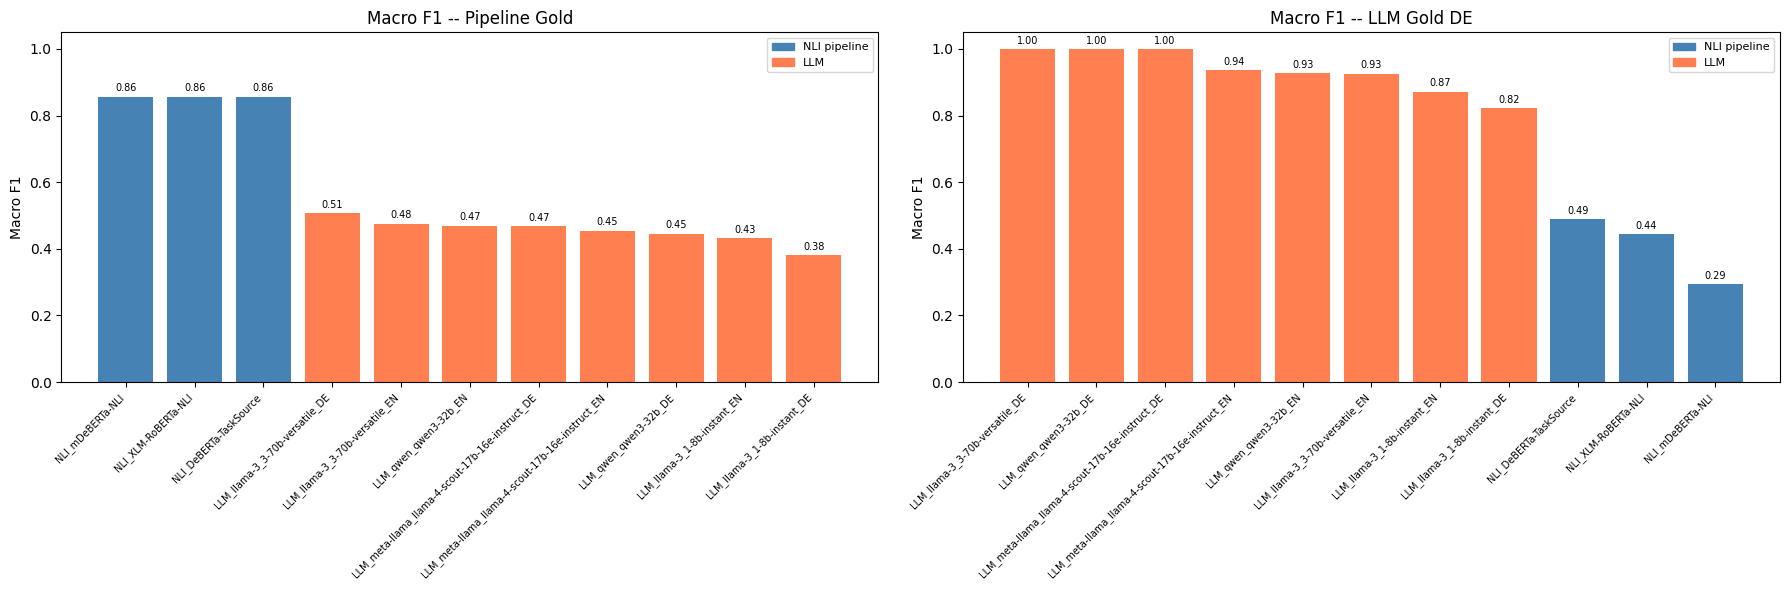

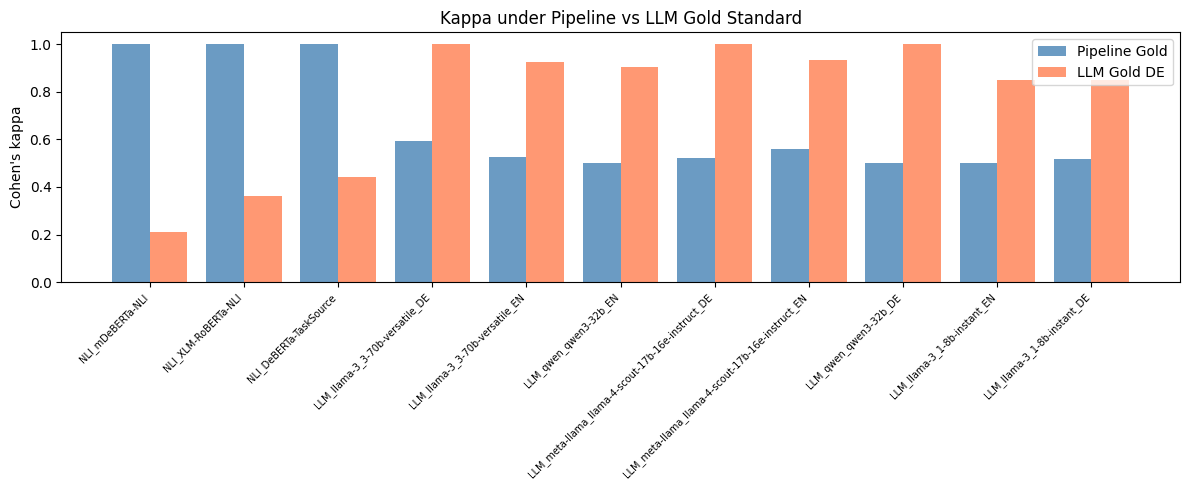

Figures saved


In [39]:

# CELL 10 : VISUALISATION

from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

def plot_bar(ax, df, metric, title, ylabel):
    systems = df["system"].tolist()
    values  = df[metric].tolist()
    colors  = ["steelblue" if "NLI" in s else "coral" for s in systems]
    bars    = ax.bar(range(len(systems)), values, color=colors)
    ax.set_xticks(range(len(systems)))
    ax.set_xticklabels(systems, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=7)
    ax.legend(handles=[Patch(color="steelblue", label="NLI pipeline"),
                        Patch(color="coral",     label="LLM")], fontsize=8)

plot_bar(axes[0], df_pg, "macro_f1", "Macro F1 -- Pipeline Gold", "Macro F1")
plot_bar(axes[1], df_lg, "macro_f1", "Macro F1 -- LLM Gold DE",   "Macro F1")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb15_f1_dual_gold.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "nb15_f1_dual_gold.png", dpi=150, bbox_inches="tight")
plt.show()

# Kappa comparison chart
fig2, ax2 = plt.subplots(figsize=(12, 5))
systems  = df_pg["system"].tolist()
kappa_pg = df_pg["kappa"].tolist()
kappa_lg = df_lg.set_index("system").reindex(systems)["kappa"].fillna(0).tolist()
x = range(len(systems))
ax2.bar([i - 0.2 for i in x], kappa_pg, width=0.4, label="Pipeline Gold",
        color="steelblue", alpha=0.8)
ax2.bar([i + 0.2 for i in x], kappa_lg, width=0.4, label="LLM Gold DE",
        color="coral", alpha=0.8)
ax2.set_xticks(list(x))
ax2.set_xticklabels(systems, rotation=45, ha="right", fontsize=7)
ax2.set_ylabel("Cohen's kappa")
ax2.set_title("Kappa under Pipeline vs LLM Gold Standard")
ax2.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb15_kappa_dual_gold.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "nb15_kappa_dual_gold.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figures saved")


In [40]:

# CELL 11 : SAVE SUMMARY JSON

summary = {
    "notebook"              : "NB15 Topic Classification",
    "timestamp"             : datetime.now().isoformat(),
    "n_validation"          : len(ARTICLE_IDS),
    "n_shared"              : len(shared_ids),
    "n_pipeline_gold"       : len(pipeline_gold),
    "n_llm_gold_de"         : len(llm_gold_de),
    "n_llm_gold_majority"   : len(llm_gold_majority),
    "inter_system_kappa": {
        "nli_pipelines"      : round(kappa_nli, 4),
        "llm_de_gold_models" : round(kappa_llm_de, 4),
    },
    "pipeline_gold_results" : [
        {k: (round(v, 4) if isinstance(v, float) else v)
         for k, v in r.items() if k != "per_cat_f1"}
        for r in results_pipeline_gold
    ],
    "llm_gold_de_results": [
        {k: (round(v, 4) if isinstance(v, float) else v)
         for k, v in r.items() if k != "per_cat_f1"}
        for r in results_llm_gold
    ],
    "language_note": (
        "All category labels, descriptions, NLI hypotheses, and LLM DE prompts "
        "are in German. LLM EN condition uses English labels and descriptions with "
        "English article text. All predictions normalised to German label space "
        "for cross-condition comparability."
    ),
}

out_path = DATA_PROC / "nb15_summary.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f"Summary saved: {out_path}")
print(json.dumps(
    {k: v for k, v in summary.items()
     if k not in ("pipeline_gold_results", "llm_gold_de_results")},
    ensure_ascii=False, indent=2
))


Summary saved: /content/drive/MyDrive/thesis/Project/Data/Processed/nb15_summary.json
{
  "notebook": "NB15 Topic Classification",
  "timestamp": "2026-06-19T18:33:25.824039",
  "n_validation": 183,
  "n_shared": 183,
  "n_pipeline_gold": 36,
  "n_llm_gold_de": 134,
  "n_llm_gold_majority": 181,
  "inter_system_kappa": {
    "nli_pipelines": 0.2741,
    "llm_de_gold_models": 0.7738
  },
  "language_note": "All category labels, descriptions, NLI hypotheses, and LLM DE prompts are in German. LLM EN condition uses English labels and descriptions with English article text. All predictions normalised to German label space for cross-condition comparability."
}
